In [1]:
!pip install wordcloud

Defaulting to user installation because normal site-packages is not writeable


In [2]:
from wordcloud import WordCloud

In [3]:
#1️⃣.Data Understanding
#Load Dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import string
import seaborn as sns
df = pd.read_excel("P652-Dataset.xlsx")
df.head()

,title,rating,body
0,Horrible product,1,Very disappointed with the overall performance...
1,Camera quality is not like 48 megapixel,3,Camera quality is low
2,Overall,4,"Got the mobile on the launch date,Battery must..."
3,A big no from me,1,1. It doesn't work with 5.0GHz WiFi frequency....
4,Put your money somewhere else,1,"Not worth buying....faulty software, poor disp..."


In [4]:
#Dataset Shape
df.shape

(1440, 3)

In [5]:
#Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   title   1440 non-null   object
 1   rating  1440 non-null   int64 
 2   body    1440 non-null   object
dtypes: int64(1), object(2)
memory usage: 33.9+ KB


In [6]:
#2️⃣.Data Quality Check
#Missing Values
df.isnull().sum()

title     0
rating    0
body      0
dtype: int64

In [7]:
#Duplicate Records
df.duplicated().sum()

0

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
#3️⃣.Target Variable Analysis
#Rating Distribution
df['rating'].value_counts().sort_index()

rating
1    386
2    126
3    199
4    310
5    419
Name: count, dtype: int64

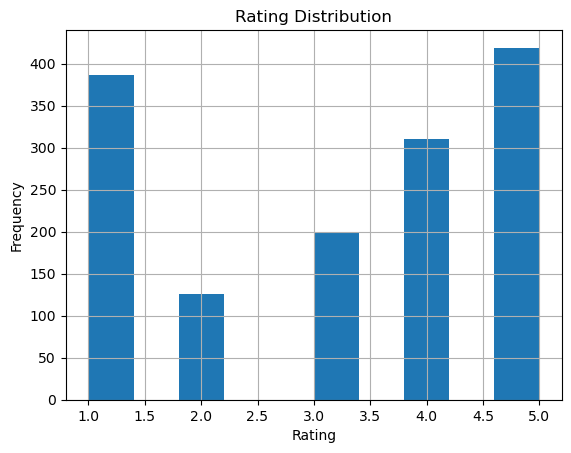

In [10]:
#Visual Distribution
plt.figure()
df['rating'].hist()
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

In [11]:
#4️⃣ Text Feature Engineering for EDA
#Combine Title + Body
df['text'] = df['title'] + " " + df['body']

In [12]:
#Review Length (Characters)
df['review_length'] = df['text'].apply(len)
df['review_length'].describe()

count    1440.000000
mean      333.381944
std       229.116704
min         9.000000
25%       198.000000
50%       277.000000
75%       395.000000
max      2536.000000
Name: review_length, dtype: float64

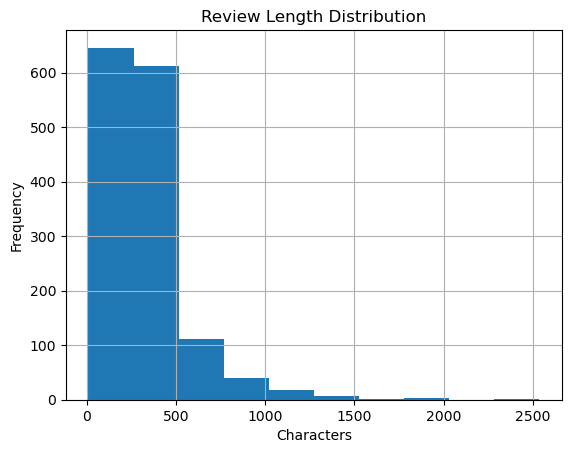

In [13]:
#Review Length Distribution
plt.figure()
df['review_length'].hist()
plt.title("Review Length Distribution")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

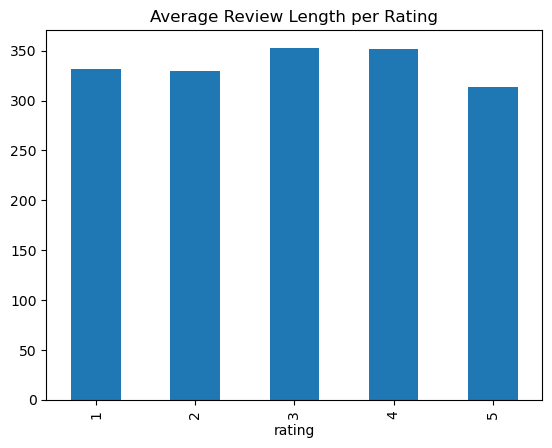

In [14]:
#Average Review Length by Rating
plt.figure()
df.groupby('rating')['review_length'].mean().plot(kind='bar')
plt.title("Average Review Length per Rating")
plt.show()

In [15]:
#5️⃣ Word Count Analysis
#Word Count Analysis
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
df['word_count'].describe()

count    1440.000000
mean       58.257639
std        39.896874
min         2.000000
25%        34.000000
50%        49.000000
75%        70.000000
max       391.000000
Name: word_count, dtype: float64

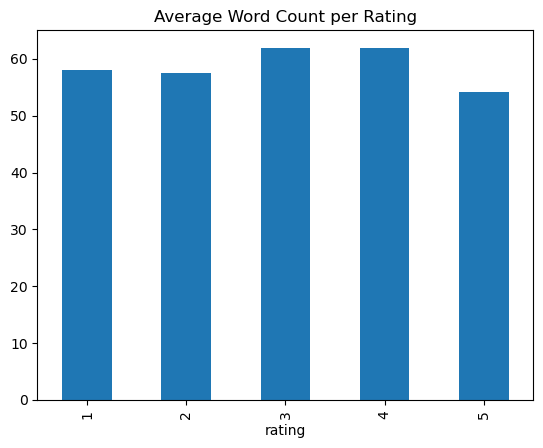

In [16]:
#Word Count vs Rating
plt.figure()
df.groupby('rating')['word_count'].mean().plot(kind='bar')
plt.title("Average Word Count per Rating")
plt.show()

In [17]:
#6️⃣ Text Cleaning for Advanced Analysis
#Text Cleaning for Advanced Analysis
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

df['clean_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ankita\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


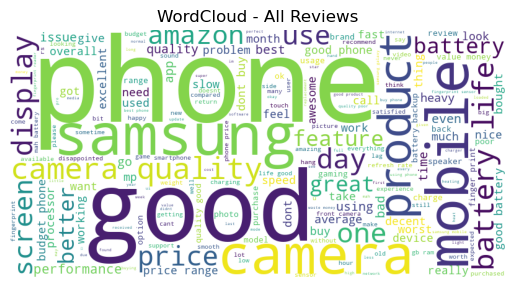

In [18]:
#7️⃣WordCloud Analysis
#WordCloud Analysis
from wordcloud import WordCloud

all_words = " ".join(df['clean_text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_words)

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud - All Reviews")
plt.show()

In [19]:
#8️⃣ Sentiment-Based Word Analysis
#Positive Reviews (4 & 5)
positive = df[df['rating'] >= 4]
positive_words = " ".join(positive['clean_text'])

In [20]:
#Negative Reviews (1 & 2)
negative = df[df['rating'] <= 2]
negative_words = " ".join(negative['clean_text'])

In [21]:
#9️⃣ Top 20 Most Frequent Words
#Top 20 Most Frequent Words
from collections import Counter

words = all_words.split()
word_freq = Counter(words)
top_20 = word_freq.most_common(20)
top_20

[('phone', 1785),
 ('good', 1353),
 ('camera', 956),
 ('battery', 803),
 ('samsung', 745),
 ('quality', 695),
 ('mobile', 587),
 ('price', 436),
 ('product', 411),
 ('buy', 336),
 ('also', 308),
 ('life', 301),
 ('display', 296),
 ('like', 288),
 ('dont', 279),
 ('better', 253),
 ('use', 252),
 ('one', 251),
 ('screen', 242),
 ('budget', 241)]

In [22]:
#🔟 Bigram Analysis (Advanced Level)
#Bigram Analysis (Advanced Level)
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
X = vectorizer.fit_transform(df['text'])

sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

words_freq[:15]

[('camera quality', 305),
 ('battery life', 281),
 ('good phone', 125),
 ('price range', 124),
 ('quality good', 109),
 ('good battery', 104),
 ('budget phone', 99),
 ('value money', 95),
 ('don buy', 92),
 ('battery backup', 92),
 ('camera good', 83),
 ('phone good', 81),
 ('finger print', 78),
 ('good camera', 74),
 ('samsung m12', 70)]

In [23]:
#1️⃣1️⃣ Correlation Analysis
#Correlation Analysis
df[['rating','review_length','word_count']].corr()

,rating,review_length,word_count
rating,1.000000,-0.017907,-0.022540
review_length,-0.017907,1.000000,0.978927
word_count,-0.022540,0.978927,1.000000


In [24]:
#Sentiment Analysis
# Create Sentiment Labels from Rating
def get_sentiment(rating):
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

df['sentiment'] = df['rating'].apply(get_sentiment)

df[['rating','sentiment']].head()

,rating,sentiment
0,1,negative
1,3,neutral
2,4,positive
3,1,negative
4,1,negative


In [25]:
#Convert Text to Features
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_text'])
y = df['sentiment']

In [26]:
#Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [27]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.7847222222222222


In [28]:
#Naive Bayes Model
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_pred = nb_model.predict(X_test)

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.7152777777777778


In [29]:
#Random Forest Model
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.7638888888888888


In [30]:
#Support Vector Machine (SVM)
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))

SVM Accuracy: 0.8020833333333334


In [31]:
#K-Nearest Neighbors (KNN)

from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier()

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, knn_pred))

KNN Accuracy: 0.7395833333333334


In [32]:
print("Logistic Regression:", accuracy_score(y_test, pred))
print("Naive Bayes:", accuracy_score(y_test, nb_pred))
print("Random Forest:", accuracy_score(y_test, rf_pred))
print("SVM:", accuracy_score(y_test, svm_pred))
print("KNN:", accuracy_score(y_test, knn_pred))

Logistic Regression: 0.7847222222222222
Naive Bayes: 0.7152777777777778
Random Forest: 0.7638888888888888
SVM: 0.8020833333333334
KNN: 0.7395833333333334


In [33]:
from sklearn.metrics import classification_report

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

    negative       0.91      0.86      0.88       111
     neutral       0.33      0.02      0.04        44
    positive       0.72      0.97      0.83       133

    accuracy                           0.78       288
   macro avg       0.65      0.62      0.58       288
weighted avg       0.73      0.78      0.73       288



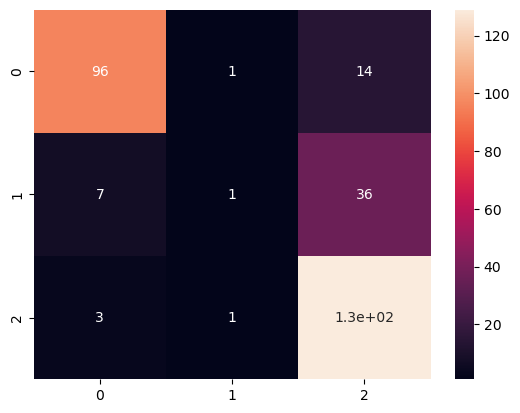

In [34]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True)
plt.show()

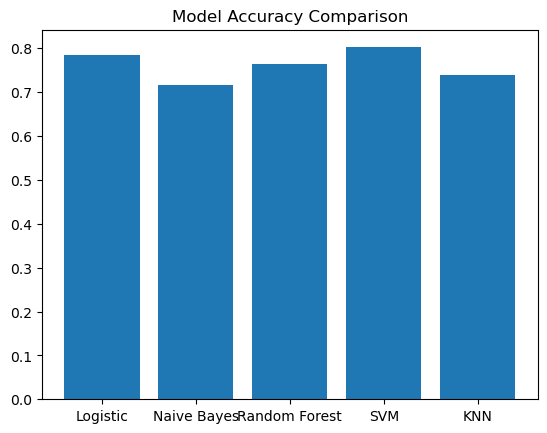

In [35]:
models = ["Logistic","Naive Bayes","Random Forest","SVM","KNN"]

accuracy = [
accuracy_score(y_test,pred),
accuracy_score(y_test,nb_pred),
accuracy_score(y_test,rf_pred),
accuracy_score(y_test,svm_pred),
accuracy_score(y_test,knn_pred)
]

plt.bar(models,accuracy)
plt.title("Model Accuracy Comparison")
plt.show()

In [36]:
import pickle

# Save SVM model
pickle.dump(svm_model, open("sentiment_model.pkl", "wb"))

# Save TF-IDF vectorizer
pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))